Saving retail_sales_dataset.csv to retail_sales_dataset.csv

COLUMNS:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

DATA PREVIEW:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

===== KPI METRICS =====
Total Sales: 4

/tmp/ipykernel_9530/2026173881.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


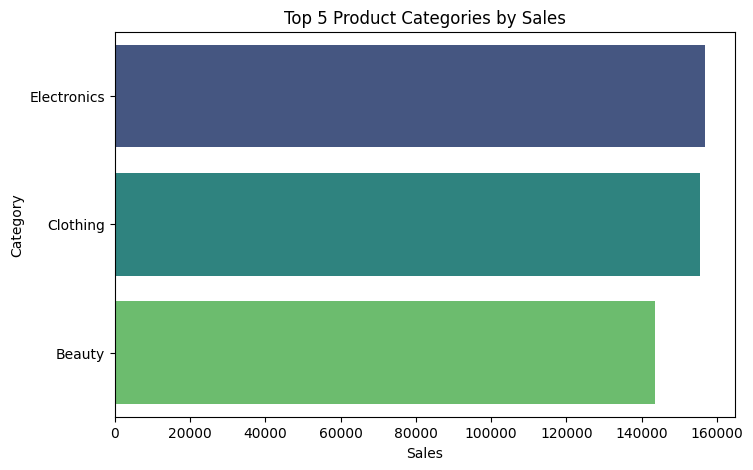

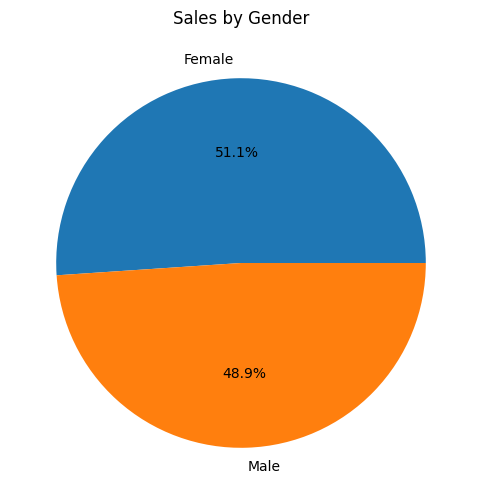

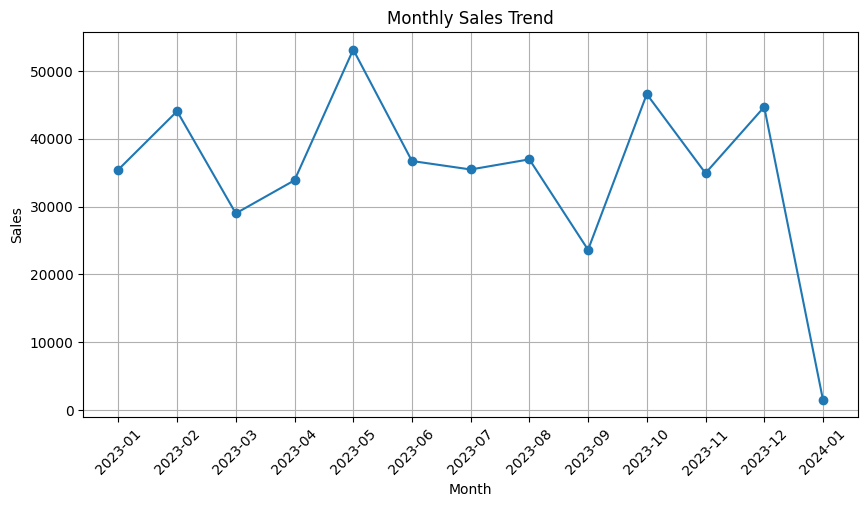


===== FINAL SUMMARY =====
Total Sales: 456000
Total Units Sold: 2514
Top Category: Electronics
Best Gender Segment: Female


In [4]:

# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. UPLOAD FILE
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv(list(uploaded.keys())[0])


# 3. CLEAN DATA

df.columns = df.columns.str.strip()

print("\nCOLUMNS:")
print(df.columns)

print("\nDATA PREVIEW:")
print(df.head())

# 4. DATE + MONTH
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

df['Month'] = df['Date'].dt.to_period('M').astype(str)


# 5. KPI METRICS
total_sales = df['Total Amount'].sum()
total_units = df['Quantity'].sum()

print("\n===== KPI METRICS =====")
print("Total Sales:", total_sales)
print("Total Units Sold:", total_units)


# 6. TOP 5 PRODUCTS (BAR CHART)
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 5 Product Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()


# 7. SALES BY GENDER (PIE CHART)
gender_sales = df.groupby('Gender')['Total Amount'].sum()

plt.figure(figsize=(6,6))
plt.pie(gender_sales.values, labels=gender_sales.index, autopct='%1.1f%%')
plt.title("Sales by Gender")
plt.show()


# 8. MONTHLY SALES TREND (LINE CHART)
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()

# 9. FINAL SUMMARY
print("\n===== FINAL SUMMARY =====")
print("Total Sales:", total_sales)
print("Total Units Sold:", total_units)
print("Top Category:", top_products.index[0])
print("Best Gender Segment:", gender_sales.idxmax())